In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
from tqdm import tqdm

from joblib import Parallel, delayed

import pickle

import schwingerModel as sim

from schwingerModel.interpolator import MesonOp, mesonMultiplet


In [8]:
def coshCorrel(nt, Energy, pivot,dimt):
    num = np.exp(-nt*Energy)+np.exp((nt-dimt)*Energy)
    denom = np.exp(-pivot*Energy)+np.exp((pivot-dimt)*Energy)
    return num/denom

In [ ]:
# with open('configs/ryanComp.pkl', 'rb') as f:
#     a1 = pickle.load(f)

In [ ]:
# sim.distillation.generateDistillFile(modelObj=a1,filePath="./configs/ryanComp.hdf5",numVecs=5,autocorrSkip=10,DNums=(0,2))

In [7]:
def triplet(op):                       # the pi+-type member: connected-only, like the old path
    return mesonMultiplet(op, 1)[+1]

In [22]:
path = "./configs/50kSteps.hdf5"
meta = sim.distillation.readDistillMeta(path)

basis1 = [triplet(MesonOp("g5")), triplet(MesonOp("g5", DNum=2))]
basis2 = basis1 + [triplet(MesonOp("gx")), triplet(MesonOp("gx", DNum=2))]

data1 = sim.GEVP.measureEnsemble(path, meta.configIndices, basis1)
data2 = sim.GEVP.measureEnsemble(path, meta.configIndices, basis2)

gevpTi = 2

out1 = sim.GEVP.bootstrapEnsemble(data1, reduce=sim.GEVP.makeGevpReduce(ti=gevpTi))
out2 = sim.GEVP.bootstrapEnsemble(data2, reduce=sim.GEVP.makeGevpReduce(ti=gevpTi))

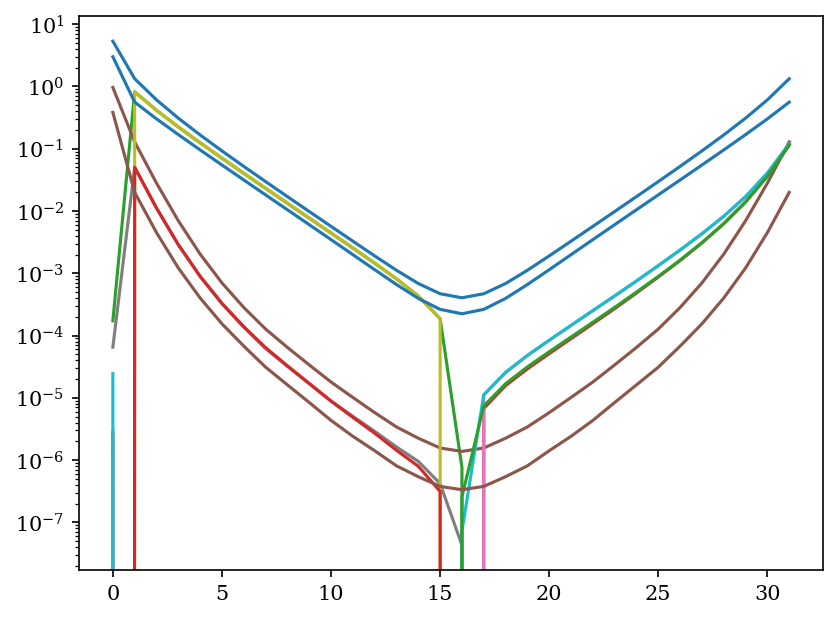

In [24]:
plt.figure(dpi=150)
plt.semilogy(np.reshape(data2['conn'][1],(16,-1)).T);

In [39]:
# fitT is in curve-index units m = t - gevpTi; window [3,6] = actual times 4..6

m0 = sim.GEVP.gevpMassExtract(out1, fitT=[5,15], ti=gevpTi, eigenIdx=0,coshExpr=True)
m1 = sim.GEVP.gevpMassExtract(out1, fitT=[5,15], ti=gevpTi, eigenIdx=1,coshExpr=True)

In [40]:
print(m0)
print(m1)

[5.90106323e-01 3.73638057e-04]
[1.35395188 0.00224349]


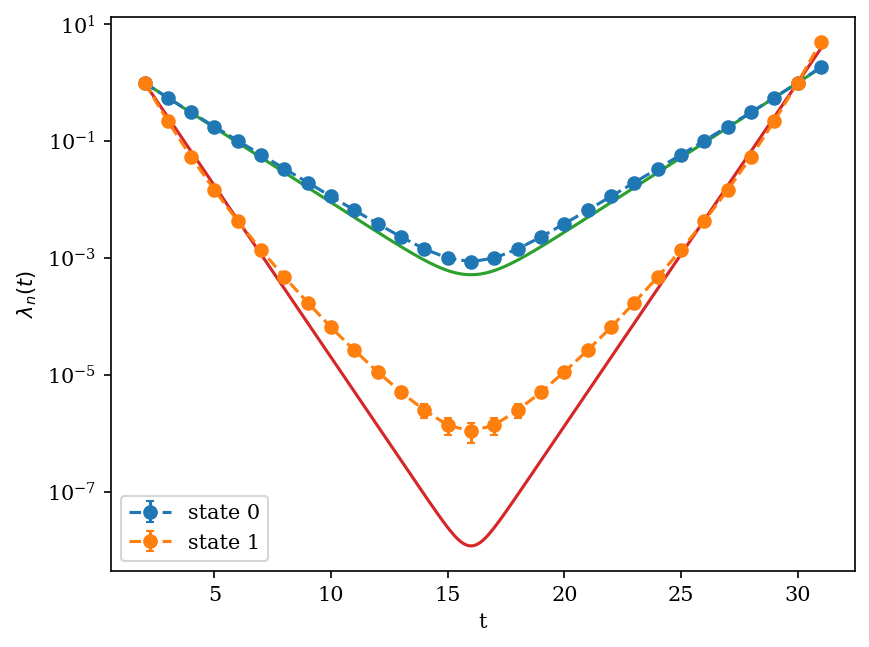

In [41]:
central, err, cov = out1

ts = np.arange(gevpTi, gevpTi + central.shape[0])   # actual times: gevpTi .. dimt-1

plt.figure(dpi=150)
for e in range(central.shape[1]):
    plt.errorbar(ts, central[:, e], yerr=err[::-1, :, e],
                 fmt='o--', capsize=2, label=f"state {e}")

# cosh references: same pivot as the gevp normalization, explicit x-axis
tf = np.linspace(gevpTi, meta.dimt - 1, 300)
plt.plot(tf, coshCorrel(tf, m0[0], gevpTi, meta.dimt))
plt.plot(tf, coshCorrel(tf, m1[0], gevpTi, meta.dimt))

plt.semilogy()
plt.xlabel("t"); plt.ylabel(r"$\lambda_n(t)$")
plt.legend()

[]

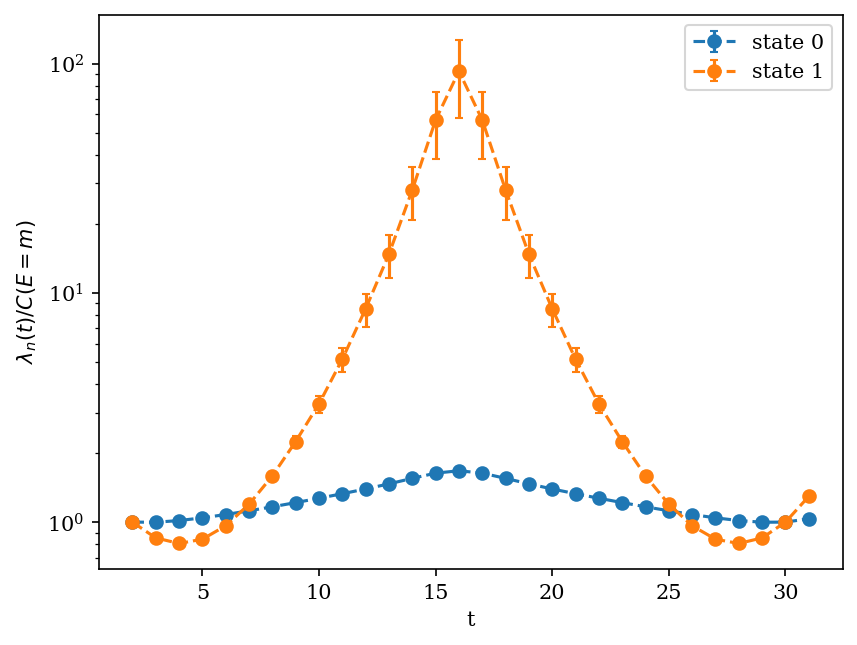

In [42]:
fits = [coshCorrel(ts, m0[0], gevpTi, meta.dimt), coshCorrel(ts, m1[0], gevpTi, meta.dimt)]

plt.figure(dpi=150)
for e in range(central.shape[1]):
    plt.errorbar(ts, central[:, e]/fits[e], yerr=err[::-1, :, e]/fits[e],
                 fmt='o--', capsize=2, label=f"state {e}")
plt.xlabel("t"); plt.ylabel(r"$\lambda_n(t)/C(E=m)$")
plt.legend()
plt.semilogy()

In [47]:
b2Masses = []
for i in range(len(basis2)):
    b2Masses.append(sim.GEVP.gevpMassExtract(out2, fitT=[2,6], ti=gevpTi, eigenIdx=i,coshExpr=False))

b2Masses = np.array(b2Masses)

In [48]:
b2Masses

array([[5.49082743e-01, 1.03014430e-03],
       [9.86338785e-01, 5.18820872e-03],
       [1.43794248e+00, 9.08349314e-03],
       [1.78571933e+00, 1.61491439e-02]])

<>:8: SyntaxWarning: invalid escape sequence '\p'
<>:8: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_44632/4114337870.py:8: SyntaxWarning: invalid escape sequence '\p'
  fmt='o--', capsize=2, label=f"m={b2Masses[e,0]:.3f} $\pm$ {b2Masses[e,1]:.3f}")


(1e-06, 10.0)

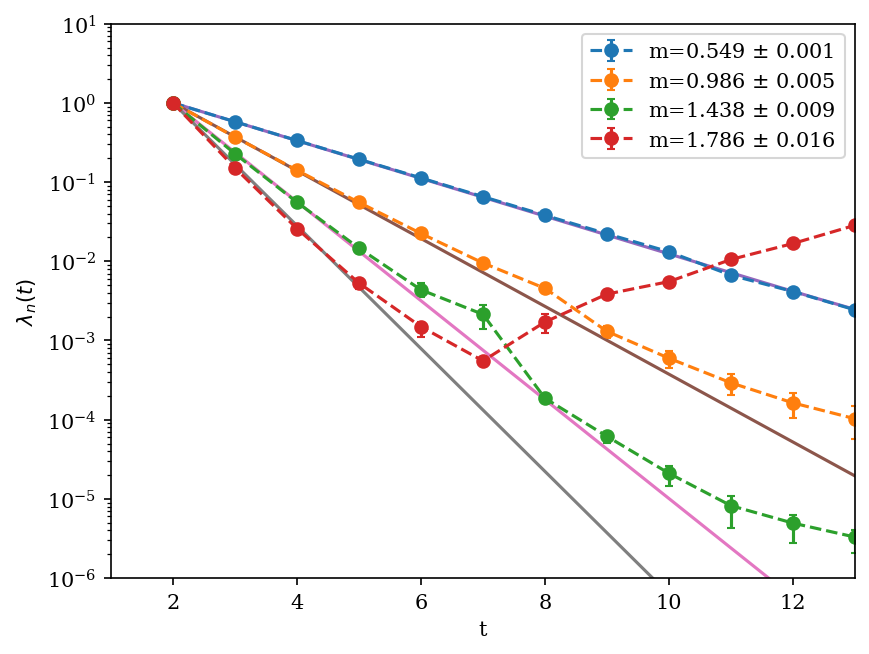

In [61]:
central, err, cov = out2

ts = np.arange(gevpTi, gevpTi + central.shape[0])   # actual times: gevpTi .. dimt-1

plt.figure(dpi=150)
for e in range(central.shape[1]):
    plt.errorbar(ts, central[:, e], yerr=err[::-1, :, e],
                 fmt='o--', capsize=2, label=f"m={b2Masses[e,0]:.3f} $\pm$ {b2Masses[e,1]:.3f}")

# cosh references: same pivot as the gevp normalization, explicit x-axis
tf = np.linspace(gevpTi, meta.dimt - 1, 300)

for i in range(len(basis2)):
    plt.plot(tf, coshCorrel(tf, b2Masses[i][0], gevpTi, meta.dimt))


plt.semilogy()
plt.xlabel("t"); plt.ylabel(r"$\lambda_n(t)$")
plt.legend()

plt.xlim([1,13])
plt.ylim([1e-6,1e1])